In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


In [30]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"  

df_2023 = pd.read_excel(file_2023, sheet_name="DATA")
df_2024 = pd.read_excel(file_2024, sheet_name="DATA")
df_2025 = pd.read_excel(file_2025, sheet_name="DATA")

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)


In [31]:
print("df_2023 shape:", df_2023.shape)
print("df_2024 shape:", df_2024.shape)
print("Combined shape:", df_all.shape)

df_2023.head(5)

df_2023 shape: (491606, 26)
df_2024 shape: (523263, 33)
Combined shape: (1503888, 33)


,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,BUYER CODE,BUYER NAME,CHEST,CATEGORY,MF/BF,MFREF,FACTORY,ELE1,ELE2,GROUP
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,S080,SUNSHINE CONSUMER LANKA,10.0,EX-ESTATE,MF,MF0062,KELANEIYA,High,WH,0
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,D332,DILMA CEYLON TEA CO PLC,10.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,U102,UNI WORLD TEAS (PVT) LT,20.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0


In [32]:
df_low = df_all[df_all["ELE1"] == "Low"].copy()
print("Low elevation rows:", len(df_low))
df_low[['YEAR', 'SALE NO', 'GRADE', 'QTY', 'PRICE', 'ELE1']].head()

Low elevation rows: 1018615


,YEAR,SALE NO,GRADE,QTY,PRICE,ELE1
62,2023,1,PF1,1120.0,1950.0,Low
63,2023,1,PF1,1120.0,2000.0,Low
176,2023,1,OP1,280.0,1700.0,Low
177,2023,1,OP,280.0,1600.0,Low
178,2023,1,OPA,260.0,1700.0,Low


In [33]:
def make_weekly_low(df_low: pd.DataFrame) -> pd.DataFrame:
    df_tmp = df_low.copy()
    df_tmp["PRICE"] = pd.to_numeric(df_tmp["PRICE"], errors="coerce")
    df_tmp["QTY"]   = pd.to_numeric(df_tmp["QTY"], errors="coerce")

    df_tmp["value"] = df_tmp["PRICE"] * df_tmp["QTY"]

    grouped = (
        df_tmp
        .groupby(["YEAR", "SALE NO", "GRADE"], as_index=False)
        .agg(
            total_qty   = ("QTY", "sum"),
            total_value = ("value", "sum"),
        )
    )

    grouped["avg_price"] = grouped["total_value"] / grouped["total_qty"]

    grouped["week_date"] = (
        pd.to_datetime(grouped["YEAR"].astype(str), format="%Y")
        + pd.to_timedelta((grouped["SALE NO"] - 1) * 7, unit="D")
    )

    return grouped[["YEAR", "SALE NO", "GRADE", "total_qty", "avg_price", "week_date"]]

weekly_low = make_weekly_low(df_low)

print("Weekly low-elevation table head:")
display(weekly_low.head())

print("\nDistinct grades in Low elevation:", weekly_low["GRADE"].nunique())
print("Sample grades:", sorted(weekly_low["GRADE"].unique())[:20])


Weekly low-elevation table head:


,YEAR,SALE NO,GRADE,total_qty,avg_price,week_date
0,2023,1,BM,242182.0,848.169104,2023-01-01
1,2023,1,BOP,61198.0,1901.850551,2023-01-01
2,2023,1,BOP1,99385.0,1903.098053,2023-01-01
3,2023,1,BOP1A,158862.0,1019.585300,2023-01-01
4,2023,1,BOPA,75373.0,1416.141987,2023-01-01



Distinct grades in Low elevation: 134
Sample grades: ['BM', 'BOP', 'BOP1', 'BOP1A', 'BOPA', 'BOPF', 'BOPFSP', 'BOPSP', 'BP', 'BP1', 'BPS', 'BT', 'BT BOP', 'BT BOP1', 'BT BOPF', 'BT FBOP', 'BT OP', 'BT OP1', 'CEYCSH', 'CIN STICKS']


In [34]:
import numpy as np
import pandas as pd

def compute_metrics(y_test, y_pred):
    """
    Robust metrics that:
      - align y_test and y_pred
      - ignore any NaNs
    """
    y_test = pd.Series(y_test).astype(float)
    y_pred = pd.Series(y_pred, index=y_test.index).astype(float)

    
    diff = y_test - y_pred

    mae  = np.nanmean(np.abs(diff))
    rmse = np.sqrt(np.nanmean(diff ** 2))

    y_safe = y_test.clip(lower=1e-3)
    mape = np.nanmean(np.abs(diff / y_safe)) * 100

    return float(mae), float(rmse), float(mape)


In [35]:
from statsmodels.tsa.arima.model import ARIMA

def select_arima_order(y, p_range=(0, 2), d_range=(0, 1), q_range=(0, 2)):
    """
    Simple ARIMA order selection using AIC on a small (p,d,q) grid.
    y: pd.Series with DateTimeIndex
    Returns: (p, d, q)
    """
    best_aic = np.inf
    best_order = (1, 1, 1)  

    for p in range(p_range[0], p_range[1] + 1):
        for d in range(d_range[0], d_range[1] + 1):
            for q in range(q_range[0], q_range[1] + 1):
                if (p, d, q) == (0, 0, 0):
                    continue
                try:
                    model = ARIMA(y, order=(p, d, q))
                    res   = model.fit()
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p, d, q)
                except Exception:
                    continue

    return best_order


In [36]:
from statsmodels.tsa.arima.model import ARIMA

def train_arima_for_grade_low(
    weekly_low: pd.DataFrame,
    grade: str,
    min_points: int = 30,
    test_weeks: int = 52,
):
    # 1) Filter / clean
    gdf = weekly_low[weekly_low["GRADE"] == grade].copy()
    gdf = gdf.sort_values("week_date").dropna(subset=["avg_price"])

    if len(gdf) < min_points:
        print(f"⚠️ Grade {grade}: only {len(gdf)} points, skipping.")
        return None

    y = pd.Series(gdf["avg_price"].values, index=gdf["week_date"]).astype(float)

    # Train / test split
    if len(y) <= test_weeks + 10:
        split_idx = int(len(y) * 0.8)
    else:
        split_idx = len(y) - test_weeks

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    history = list(y_train.values)
    preds   = []

    for t in range(len(y_test)):
        model = ARIMA(history, order=(1, 1, 1))
        res   = model.fit()
        preds.append(res.forecast(steps=1)[0])

        # update history with the TRUE observed value
        history.append(y_test.iloc[t])

    y_pred = pd.Series(preds, index=y_test.index)

    # Metrics from rolling predictions
    diff = y_test - y_pred
    mae  = float(np.nanmean(np.abs(diff)))
    rmse = float(np.nanmean(diff**2) ** 0.5)
    mape = float(np.nanmean(np.abs(diff / y_test.clip(lower=1e-3))) * 100)

    # Refit on full series for FUTURE (this can still give a “flatter” curve,
    model_full = ARIMA(y, order=(1, 1, 1)).fit()

    return {
        "grade": grade,
        "n_points": len(y),
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "model": model_full,
        "y_price": y,
        "y_test_price": y_test,
        "y_pred_test_price": y_pred,   # now rolling 1-step, NOT flat
    }


In [37]:
results_low_arima = []
models_low_arima  = {}

for g in sorted(weekly_low["GRADE"].unique()):
    print(f"→ Grade {g}")
    info = train_arima_for_grade_low(weekly_low, g)

    if info is None:
        continue

    results_low_arima.append({
        "elevation": "Low",
        "grade": info["grade"],
        "n_points": info["n_points"],
        "MAE": info["mae"],
        "RMSE": info["rmse"],
        "MAPE_%": info["mape"],
    })
    models_low_arima[g] = info

metrics_low_arima = pd.DataFrame(results_low_arima).sort_values("MAPE_%")
display(metrics_low_arima.head(20))



→ Grade BM


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


→ Grade BOP


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-s

→ Grade BOP1


...

→ Grade PURPLE TEA
⚠️ Grade PURPLE TEA: only 1 points, skipping.
→ Grade S/TIPPS


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


→ Grade SENCHA
⚠️ Grade SENCHA: only 6 points, skipping.
→ Grade SILVER TIP
→ Grade SILVERTIPS
⚠️ Grade SILVERTIPS: only 18 points, skipping.
→ Grade SIVER CURL
⚠️ Grade SIVER CURL: only 1 points, skipping.
→ Grade VANILLA RO
⚠️ Grade VANILLA RO: only 1 points, skipping.
→ Grade WHITE LINE
⚠️ Grade WHITE LINE: only 1 points, skipping.
→ Grade WHITE TEA
→ Grade WHITE TIP
⚠️ Grade WHITE TIP: only 2 points, skipping.
→ Grade WILD TEA
⚠️ Grade WILD TEA: only 1 points, skipping.
→ Grade WT FGS
⚠️ Grade WT FGS: only 2 points, skipping.
→ Grade WT OP
⚠️ Grade WT OP: only 3 points, skipping.


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.

,elevation,grade,n_points,MAE,RMSE,MAPE_%
0,Low,BM,147,9.123204,11.604279,1.100162
31,Low,PEK,147,17.777109,21.377187,1.265860
32,Low,PEK1,147,22.027958,27.809653,1.348253
22,Low,FGS,147,10.883502,13.769747,1.379349
3,Low,BOP1A,147,12.880289,16.062585,1.440985
14,Low,FBOP,147,22.664116,31.974599,1.545409
27,Low,OP,147,21.179408,25.560657,1.670864
17,Low,FBOPF1,147,23.987296,31.905612,1.809907
29,Low,OPA,147,21.413553,26.803186,1.823828
11,Low,BT,147,15.134065,18.643941,1.862387


In [38]:
metrics_low_arima.to_csv("low_elevation_arima_metrics.csv", index=False)


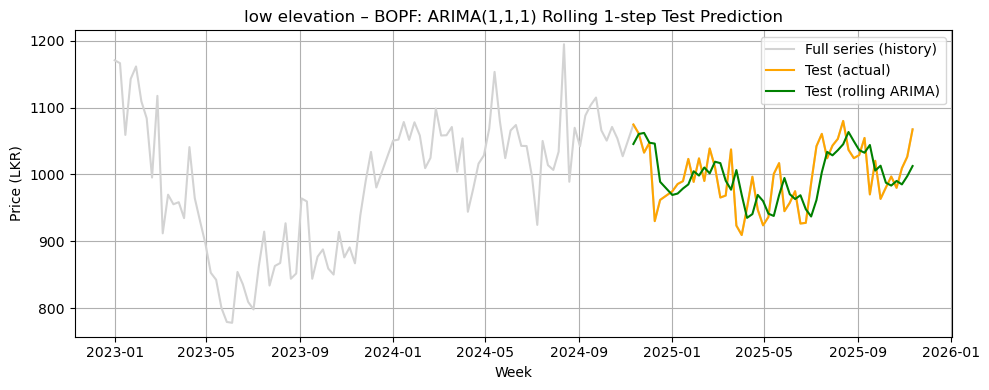

Rolling 1-step: MAE=31.93, RMSE=39.97, MAPE=3.23%


In [39]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rolling_arima_forecast(y, order=(1,1,1), test_weeks=52):
    """
    y: pd.Series with DateTimeIndex
    Returns:
      y_train, y_test, y_pred_rolling
    """
    if len(y) <= test_weeks + 10:
        split_idx = int(len(y) * 0.8)
    else:
        split_idx = len(y) - test_weeks

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    history = list(y_train.values)
    preds   = []
    
    for t in range(len(y_test)):
        model = ARIMA(history, order=order)
        res   = model.fit()
        preds.append(res.forecast(steps=1)[0])
        history.append(y_test.iloc[t])  # <-- update with TRUE value


    y_pred_roll = pd.Series(preds, index=y_test.index)
    return y_train, y_test, y_pred_roll

# ----- low – BOPF example -----
gdf_low = weekly_low[weekly_low["GRADE"] == "BOPF"].copy()
gdf_low = gdf_low.sort_values("week_date").dropna(subset=["avg_price"])

y_low = pd.Series(gdf_low["avg_price"].values,
                  index=gdf_low["week_date"]).astype(float)

y_train, y_test, y_pred_roll = rolling_arima_forecast(
    y_low, order=(1,1,1), test_weeks=52
)

# Plot
plt.figure(figsize=(10,4))
plt.plot(y_low.index, y_low.values, color="lightgray",
         label="Full series (history)")
plt.plot(y_test.index, y_test.values, label="Test (actual)", color="orange")
plt.plot(y_pred_roll.index, y_pred_roll.values,
         label="Test (rolling ARIMA)", color="green")
plt.title("low elevation – BOPF: ARIMA(1,1,1) Rolling 1-step Test Prediction")
plt.ylabel("Price (LKR)")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.show()

# Metrics for rolling forecast
diff = y_test - y_pred_roll
mae  = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
mape = np.mean(np.abs(diff / y_test.clip(lower=1e-3))) * 100
print(f"Rolling 1-step: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")



In [40]:
def print_metrics_for_low_arima_grade(grade="BOPF"):
    info = models_low_arima[grade]
    mae  = info["mae"]
    rmse = info["rmse"]
    mape = info["mape"]

    print(f"ARIMA – Low elevation – {grade}")
    print(f"  MAE  : {mae:.6f} LKR")
    print(f"  RMSE : {rmse:.6f} LKR")
    print(f"  MAPE : {mape:.6f} %")


# Example:
print_metrics_for_low_arima_grade("BOPF")

ARIMA – Low elevation – BOPF
  MAE  : 31.934925 LKR
  RMSE : 39.965495 LKR
  MAPE : 3.228299 %


In [41]:
metrics_low_arima_all = metrics_low_arima.sort_values("MAPE_%")
display(metrics_low_arima_all.head(20))


,elevation,grade,n_points,MAE,RMSE,MAPE_%
0,Low,BM,147,9.123204,11.604279,1.100162
31,Low,PEK,147,17.777109,21.377187,1.265860
32,Low,PEK1,147,22.027958,27.809653,1.348253
22,Low,FGS,147,10.883502,13.769747,1.379349
3,Low,BOP1A,147,12.880289,16.062585,1.440985
14,Low,FBOP,147,22.664116,31.974599,1.545409
27,Low,OP,147,21.179408,25.560657,1.670864
17,Low,FBOPF1,147,23.987296,31.905612,1.809907
29,Low,OPA,147,21.413553,26.803186,1.823828
11,Low,BT,147,15.134065,18.643941,1.862387


In [42]:
future_rows_arima = []

N_FUTURE_WEEKS = 52  # forecast one year ahead

for g, info in models_low_arima.items():
    model = info["model"]          # full-series ARIMA
    y_price_full = info["y_price"]

    last_date = y_price_full.index[-1]

    # future weekly index
    future_index = pd.date_range(
        start=last_date + pd.Timedelta(days=7),
        periods=N_FUTURE_WEEKS,
        freq="7D"
    )

    # ARIMA forecast
    future_vals = model.forecast(steps=N_FUTURE_WEEKS)
    future_series = pd.Series(np.asarray(future_vals, float), index=future_index)

    tmp = pd.DataFrame({
        "elevation": "Low",
        "grade": g,
        "date": future_series.index,
        "predicted_price": future_series.values,
    })
    future_rows_arima.append(tmp)

future_low_arima_df = pd.concat(future_rows_arima, ignore_index=True)


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_pre

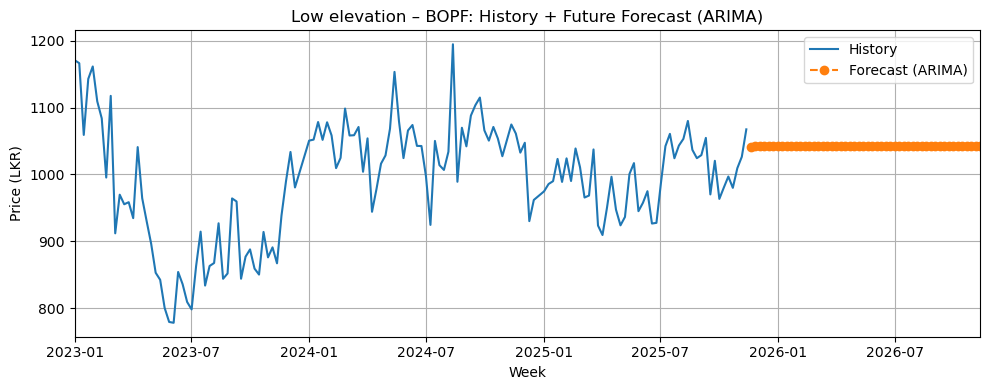

In [43]:
grade_for_demo = "BOPF"

hist_low = models_low_arima[grade_for_demo]["y_price"]
future_grade = future_low_arima_df[future_low_arima_df["grade"] == grade_for_demo]

plt.figure(figsize=(10, 4))
plt.plot(hist_low.index, hist_low.values, label="History")

plt.plot(
    future_grade["date"],
    future_grade["predicted_price"],
    marker="o",
    linestyle="--",
    label="Forecast (ARIMA)",
)

# make sure x-axis covers both history + future
plt.xlim(hist_low.index.min(), future_grade["date"].max())

plt.title(f"Low elevation – {grade_for_demo}: History + Future Forecast (ARIMA)")
plt.ylabel("Price (LKR)")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.show()


In [44]:
grade = "BOPF"
info = models_low_arima[grade]

y_test = info["y_test_price"]
y_pred = info["y_pred_test_price"]

print("len(y_test):", len(y_test))
print("len(y_pred):", len(y_pred))

cmp = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
print(cmp.head(10))

print("\nDifferences:")
print((cmp["y_test"] - cmp["y_pred"]).abs().describe())


len(y_test): 52
len(y_pred): 52
                 y_test       y_pred
week_date                           
2024-11-11  1074.699087  1045.546624
2024-11-18  1061.135178  1060.454884
2024-11-25  1032.622590  1062.101028
2024-12-02  1047.367476  1047.453792
2024-12-09   930.171836  1046.095372
2024-12-16   961.835546   988.988215
2025-01-01   974.730188   969.284965
2025-01-08   985.671834   971.411115
2025-01-15   989.966692   978.931612
2025-01-22  1023.232537   985.076392

Differences:
count     52.000000
mean      31.934925
std       24.263614
min        0.086316
25%       14.084456
50%       25.510122
75%       49.619163
max      115.923536
dtype: float64


In [47]:
import statsmodels.api as sm

def diagnose_arima_in_sample(models_dict, grade: str, elevation_label: str = "Low"):
    """
    In-sample residual diagnostics for ARIMA model of a given grade.
    Uses the full-series model stored in models_*_arima[grade]["model"].
    """
    if grade not in models_dict:
        raise KeyError(f"Grade {grade} not found. Available: {list(models_dict.keys())}")

    info = models_dict[grade]
    model_full = info["model"]      # ARIMA fitted on full series
    resid = pd.Series(model_full.resid)

    print(f"=== In-sample residual diagnostics – {elevation_label} – {grade} – ARIMA ===\n")

    # Basic stats
    print("Residual summary:")
    print(resid.describe())
    print("\nMean residual (should be close to 0):", resid.mean())

    # Ljung–Box test for autocorrelation at lags 10, 20, 30
    # (drop NaNs just in case)
    resid_clean = resid.dropna()
    lb = sm.stats.acorr_ljungbox(resid_clean, lags=[10, 20, 30], return_df=True)
    print("\nLjung–Box test for residual autocorrelation:")
    print(lb)

    # Plots
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    # Time plot of residuals
    axes[0, 0].plot(resid.index, resid.values)
    axes[0, 0].axhline(0, color='black', linewidth=1)
    axes[0, 0].set_title("Residuals over time")
    axes[0, 0].set_xlabel("Week")
    axes[0, 0].set_ylabel("Residual")

    # Histogram
    axes[0, 1].hist(resid.values, bins=20)
    axes[0, 1].set_title("Residual histogram")

    # ACF of residuals
    sm.graphics.tsa.plot_acf(resid_clean, ax=axes[1, 0], lags=30)
    axes[1, 0].set_title("ACF of residuals")

    # QQ-plot
    sm.qqplot(resid_clean, line='s', ax=axes[1, 1])
    axes[1, 1].set_title("QQ-plot of residuals")

    plt.tight_layout()
    plt.show()

    return lb, resid

In [49]:
def full_arima_diagnostics_for_grade(models_dict, grade: str, elevation_label: str = "Low"):
    print("\n" + "="*80)
    print(f"ARIMA diagnostics for {elevation_label} – {grade}")
    print("="*80 + "\n")

    lb_df, resid_full = diagnose_arima_in_sample(models_dict, grade, elevation_label)
    resid_test = diagnose_arima_test_residuals(models_dict, grade, elevation_label)

    return lb_df, resid_full, resid_test



ARIMA diagnostics for Low – BOPF

=== In-sample residual diagnostics – Low – BOPF – ARIMA ===

Residual summary:
count     147.000000
mean        6.344938
std       108.940879
min      -170.814101
25%       -26.314502
50%        -6.538145
75%        30.346766
max      1170.756476
dtype: float64

Mean residual (should be close to 0): 6.34493841431557

Ljung–Box test for residual autocorrelation:
      lb_stat  lb_pvalue
10   5.884043   0.824910
20   7.766913   0.993301
30  10.601885   0.999587


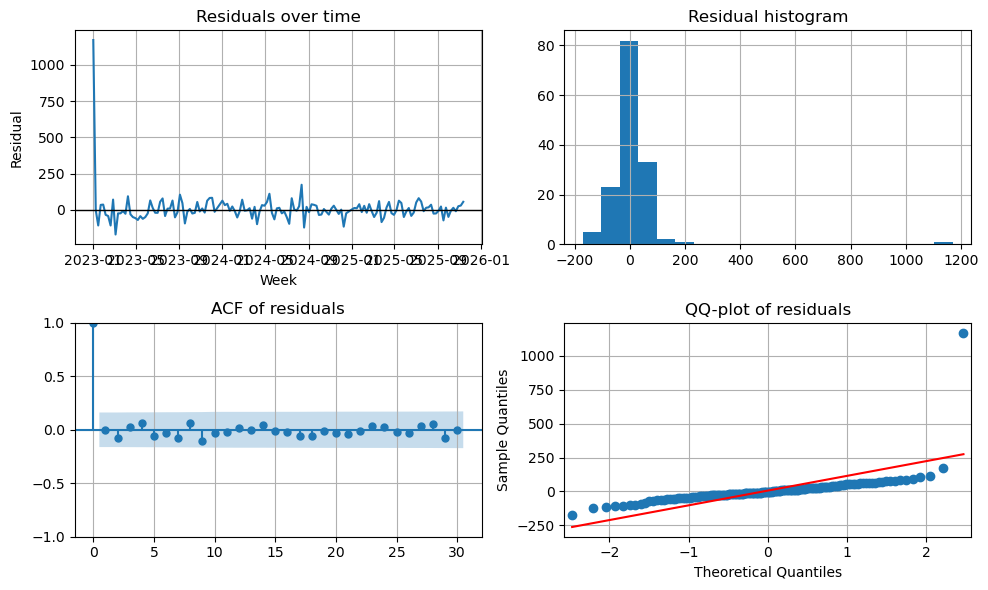

=== Test residual diagnostics – Low – BOPF – ARIMA ===

Test residual summary:
count     52.000000
mean      -0.078561
std       40.355334
min     -115.923536
25%      -22.998466
50%        0.296989
75%       26.567839
max       80.505776
dtype: float64

Mean test residual: -0.078561120307042
Std of test residual: 40.35533364128403


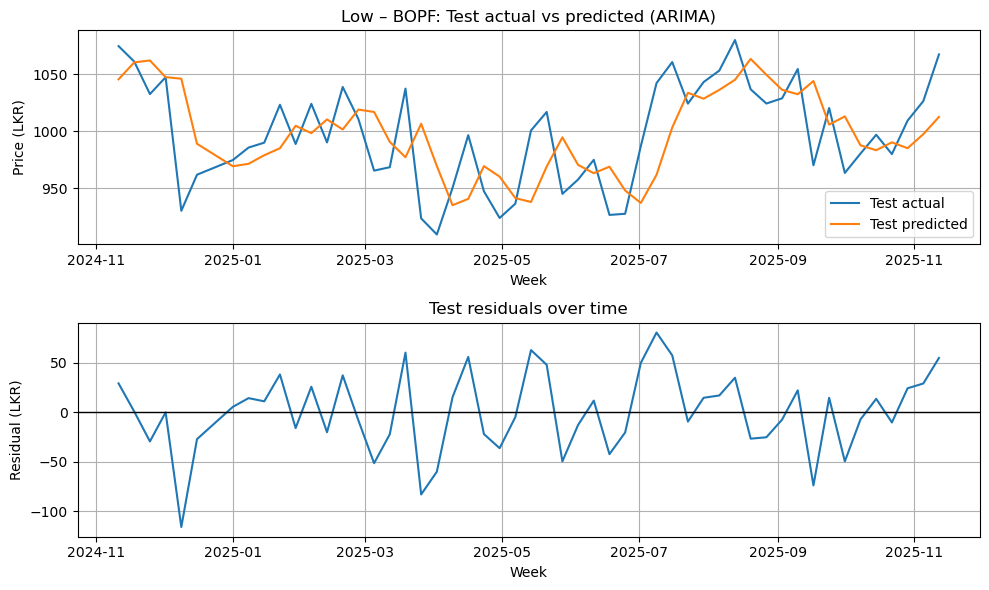

In [55]:
lb_low_bopf, resid_low_bopf, test_resid_low_bopf = full_arima_diagnostics_for_grade(
    models_low_arima,
    grade="BOPF",
    elevation_label="Low"
)



Residuals over time
Shows how the model errors change week by week.
For Low–BOPF, there is one big spike at the beginning (an outlier week), but afterwards the residuals are small and fluctuate around zero → the model fits most weeks well.#

Residual histogram
Shows the distribution of errors.
Most residuals are close to zero, with one bar far to the right from the big early outlier. Apart from that, the errors are centred near zero.

ACF of residuals-
Checks whether residuals are still correlated with previous weeks.
All bars (except lag 0) are inside the blue band, and the Ljung–Box p-values are > 0.9, so there is no significant autocorrelation → the ARIMA model has captured the time pattern.

QQ-plot of residuals
Compares residuals to a normal distribution.
Points follow the straight line in the middle and deviate in the tails because of the outlier. This means residuals are roughly normal with some heavy tails due to a few extreme weeks.

In [51]:
import matplotlib.pyplot as plt

def plot_train_test_split(weekly_df, elevation_label: str, grade: str = "BOPF", n_test: int = 52):
    """
    Plot actual weekly price with Train vs Test split.

    weekly_df      : DataFrame with columns ["ELEVATION", "GRADE", "week_date", "avg_price"]
    elevation_label: just for title ("Low", "Medium", "High")
    grade          : tea grade, e.g. "BOPF"
    n_test         : number of last weeks used as TEST (e.g. 52)
    """

    # 1) Filter for the selected grade and sort by date
    gdf = weekly_df[weekly_df["GRADE"] == grade].copy()
    gdf = gdf.sort_values("week_date")

    if gdf.empty:
        print(f"No data found for {elevation_label} – {grade}")
        return

    # 2) Build a time series indexed by week_date
    y = gdf.set_index("week_date")["avg_price"].astype(float)

    if len(y) <= n_test:
        print(f"Not enough points for {elevation_label} – {grade}. Length={len(y)}, n_test={n_test}")
        return

    # 3) Split into train and test (last n_test weeks = test)
    split_idx = len(y) - n_test
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    print(f"=== {elevation_label} – {grade} ===")
    print(f"Total points: {len(y)}")
    print(f"Train points: {len(y_train)}  ({y_train.index[0].date()} → {y_train.index[-1].date()})")
    print(f"Test points : {len(y_test)}   ({y_test.index[0].date()} → {y_test.index[-1].date()})")

    # 4) Plot
    plt.figure(figsize=(10, 4))
    plt.plot(y.index, y.values, color="lightgray", label="Full series (actual)")

    plt.plot(y_train.index, y_train.values, label="Train (actual)", color="blue")
    plt.plot(y_test.index,  y_test.values,  label="Test (actual)",  color="orange")

    # vertical line at split
    split_date = y_test.index[0]
    plt.axvline(split_date, color="red", linestyle="--", label=f"Split ({split_date.date()})")

    plt.title(f"{elevation_label} – {grade}: Weekly price (Train vs Test)")
    plt.xlabel("Week")
    plt.ylabel("Average price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== Low – BOPF ===
Total points: 147
Train points: 95  (2023-01-01 → 2024-11-04)
Test points : 52   (2024-11-11 → 2025-11-12)


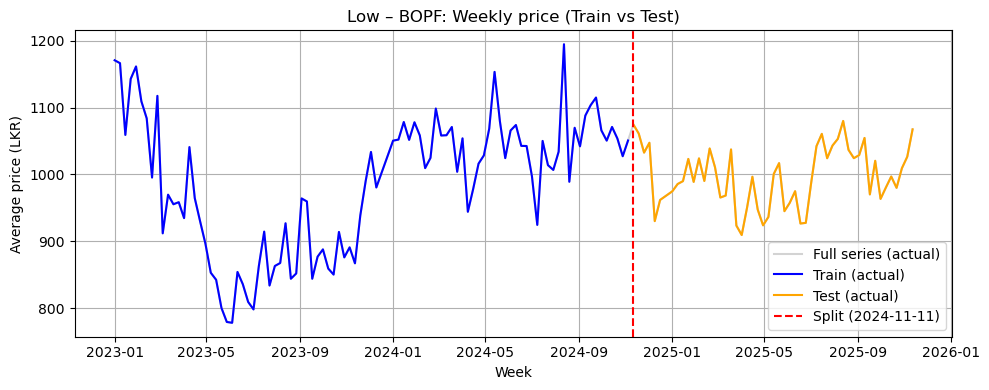

In [52]:
# Low elevation – BOPF
plot_train_test_split(weekly_low, "Low", "BOPF", n_test=52)


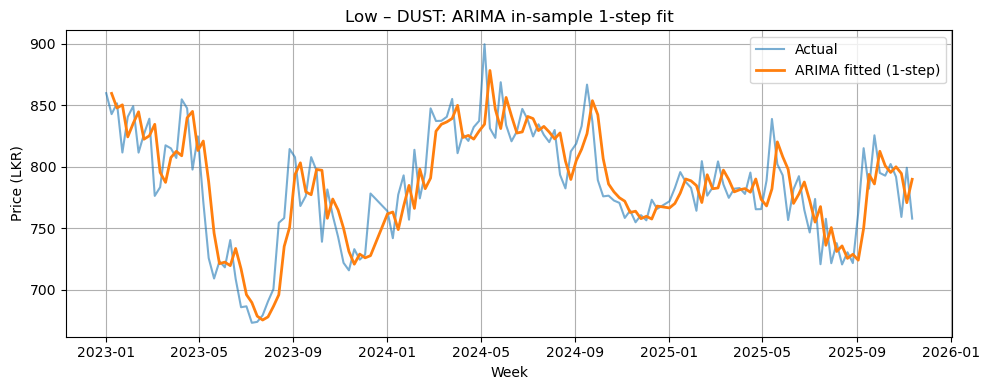

In [53]:
grade = "DUST"
info = models_low_arima[grade]

model_full = info["model"]
y = info["y_price"]   # full actual series

# 1-step-ahead in-sample predictions (dynamic=False)
fitted = model_full.predict(start=y.index[1], end=y.index[-1], dynamic=False)

plt.figure(figsize=(10,4))
plt.plot(y.index, y.values, label="Actual", alpha=0.6)
plt.plot(fitted.index, fitted.values, label="ARIMA fitted (1-step)", linewidth=2)
plt.title("Low – DUST: ARIMA in-sample 1-step fit")
plt.xlabel("Week")
plt.ylabel("Price (LKR)")
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
import pickle

# Save the ARIMA model to a file
with open("arima_low_grade_model.pkl", "wb") as f:
    pickle.dump(models_low_arima[grade_for_demo]["model"], f)
